In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display

In [3]:
class CircleFit:
  def __init__(self, alpha, max_iter) -> None:
    self.alpha = alpha
    self.max_iter = max_iter
    self.a = 0
    self.b = 0
    self.r = 0

  def J(self, X, m):
    dist_center = np.linalg.norm(X - (self.a,self.b), axis=1)
    dist_circle = dist_center - self.r
    return np.sum(dist_circle**2) / m

  def fit(self, X, termination_diff, verbose=0):
    m = len(X)

    # initialize variables
    self.a = np.mean(X[:,0])
    self.b = np.mean(X[:,1])
    self.r = 1

    history = {}
    old_loss = np.inf
    for iter in range(self.max_iter):
      curr_loss = self.J(X, m)
      history[iter] = {
          "loss": curr_loss,
          "a": self.a,
          "b": self.b,
          "r": self.r
      }

      if verbose == 2:
        print(f"Iter {iter} -> Loss: {curr_loss}")

      if verbose == 1 and iter % 10 == 0:
        print(f"Iter {iter} -> Loss: {curr_loss}")

      if np.abs(old_loss - curr_loss) < termination_diff:
        break

      old_loss = curr_loss

      diff = X - np.array([self.a, self.b])
      dist_center = np.linalg.norm(diff, axis=1) + 1e-8

      left = 1.0 - (self.r / dist_center)

      J_a = (-2.0 / m) * np.sum(left * diff[:, 0])
      J_b = (-2.0 / m) * np.sum(left * diff[:, 1])
      J_r = (-2.0 / m) * np.sum(dist_center - self.r)

      self.a -= self.alpha * J_a
      self.b -= self.alpha * J_b
      self.r -= self.alpha * J_r

    print(f"Final loss: {self.J(X, m)}")
    return history

  def get_params(self):
    return self.a, self.b, self.r


In [4]:
def generate_ring_dataset(radius, center, n_samples, noise):
    angles = np.random.uniform(0, 2 * np.pi, n_samples)

    r = radius + np.random.normal(0, noise, n_samples)

    x = center[0] + r * np.cos(angles)
    y = center[1] + r * np.sin(angles)

    return np.column_stack((x, y))

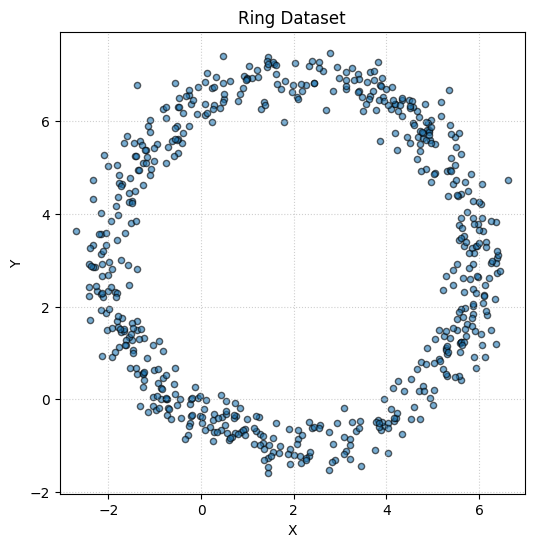

In [5]:
data = generate_ring_dataset(
    radius=4.0,
    center=(2.0, 3.0),
    n_samples=600,
    noise=0.3
)

# Çizdir
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k', s=20)
plt.title("Ring Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [6]:
model = CircleFit(alpha=0.005, max_iter=1000)
history = model.fit(data, termination_diff=0.0001, verbose=1)

Iter 0 -> Loss: 9.067923715198834
Iter 10 -> Loss: 7.434663503687652
Iter 20 -> Loss: 6.098788479780028
Iter 30 -> Loss: 5.006145554663632
Iter 40 -> Loss: 4.112443138792716
Iter 50 -> Loss: 3.381455273680791
Iter 60 -> Loss: 2.783552824423922
Iter 70 -> Loss: 2.294502162232692
Iter 80 -> Loss: 1.8944826192093758
Iter 90 -> Loss: 1.5672828722012282
Iter 100 -> Loss: 1.2996436698755045
Iter 110 -> Loss: 1.0807202521861132
Iter 120 -> Loss: 0.9016426652122495
Iter 130 -> Loss: 0.7551561440075628
Iter 140 -> Loss: 0.6353269827136975
Iter 150 -> Loss: 0.5373019664954313
Iter 160 -> Loss: 0.45711161156378355
Iter 170 -> Loss: 0.3915092357560192
Iter 180 -> Loss: 0.33783933487463796
Iter 190 -> Loss: 0.2939299281646623
Iter 200 -> Loss: 0.25800450811147113
Iter 210 -> Loss: 0.2286100245754496
Iter 220 -> Loss: 0.20455798337299683
Iter 230 -> Loss: 0.18487627112451568
Iter 240 -> Loss: 0.168769753076915
Iter 250 -> Loss: 0.15558804630282122
Iter 260 -> Loss: 0.1447991616021282
Iter 270 -> Los

In [7]:
iters = []
losees = []
a_s = []
b_s = []
r_s = []
for key, value in history.items():
  iters.append(key)
  losees.append(value["loss"])
  a_s.append(value["a"])
  b_s.append(value["b"])
  r_s.append(value["r"])

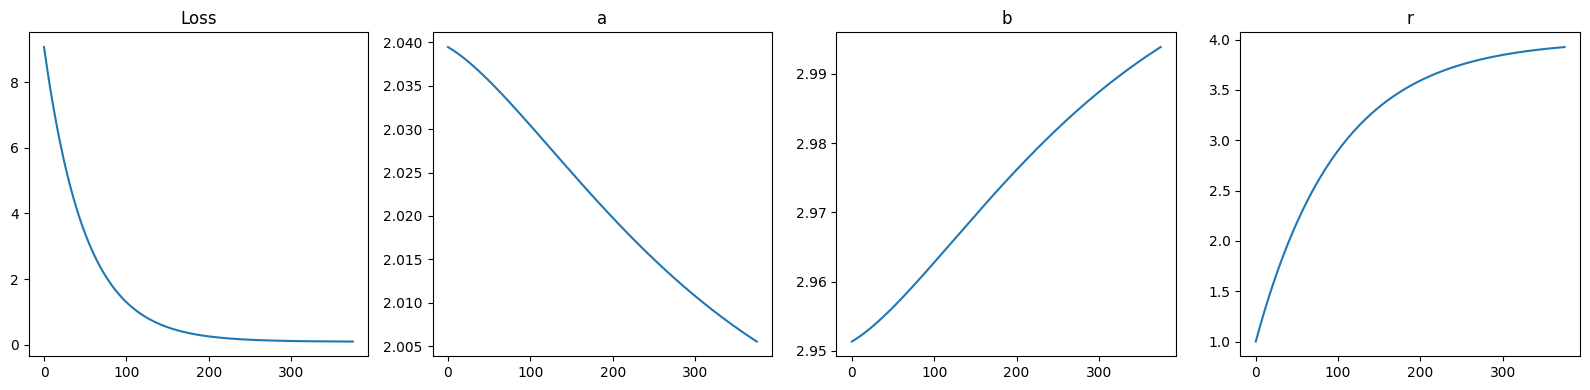

In [15]:
fig, axs = plt.subplots(1,4, figsize=(16,4))

axs[0].plot(iters, losees)
axs[0].set_title("Loss")

axs[1].plot(iters, a_s)
axs[1].set_title("a")

axs[2].plot(iters, b_s)
axs[2].set_title("b")

axs[3].plot(iters, r_s)
axs[3].set_title("r")

plt.tight_layout()

In [16]:
a, b, r = model.get_params()
print(f"a: {a}, b: {b}, r: {r}")

a: 2.0055435654398797, b: 2.993849168446095, r: 3.92626108825304


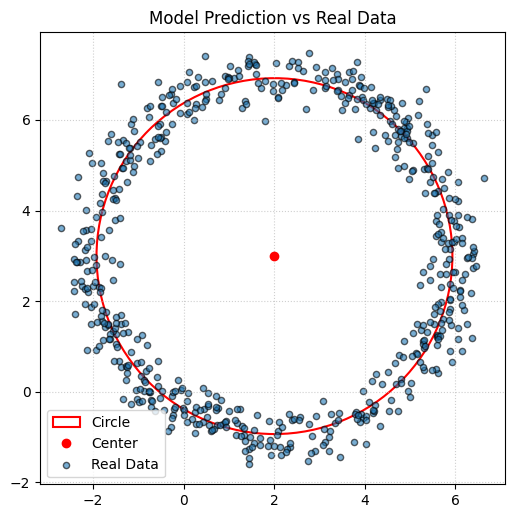

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

circle = plt.Circle((a, b), r, color='red', fill=False, linewidth=1.5, label='Circle')
ax.add_patch(circle)

ax.plot(a, b, 'ro', label='Center')
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k', s=20, label="Real Data")

ax.set_aspect('equal')

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("Model Prediction vs Real Data")
plt.show()

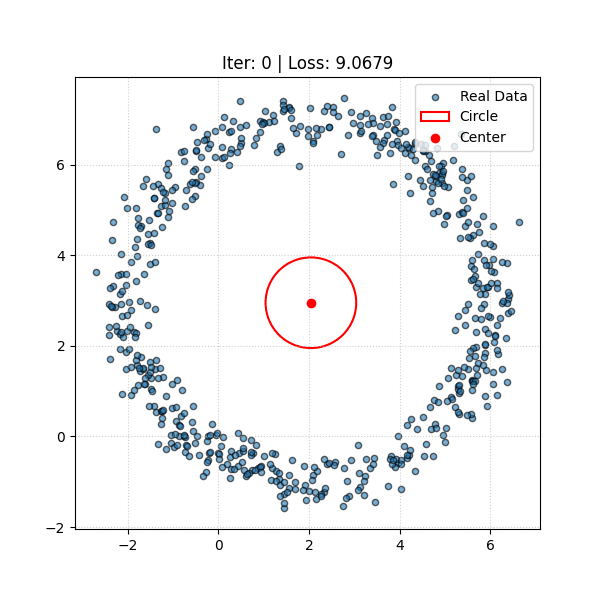

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k', s=20, label="Real Data")

circle = plt.Circle((a_s[0], b_s[0]), r_s[0], color='red', fill=False, linewidth=1.5, label='Circle')
ax.add_patch(circle)

center, = ax.plot([], [], 'ro', label='Center')

ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

def update(frame):
    current_a = a_s[frame]
    current_b = b_s[frame]
    current_r = r_s[frame]
    current_loss = losees[frame]

    circle.set_center((current_a, current_b))
    circle.set_radius(current_r)
    center.set_data([current_a], [current_b])

    ax.set_title(f"Iter: {iters[frame]} | Loss: {current_loss:.4f}")

    return circle, center

anim = FuncAnimation(
    fig,
    update,
    frames=len(iters),
    interval=50,
    repeat=True,
    repeat_delay=10000
)

plt.close(fig)

anim.save('circle_fit.gif', writer='pillow', fps=15)
display(Image(filename='circle_fit.gif'))